##  Estimate super-/sub-community membership for TlF CID 

This notebook runs the temporally stabilized community estimation algorithm, and produces several charts, among others a dashboard 
sued as basis for our discussion of the estimation results.   

In [1]:
# imports 
# load adjacency matrices 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle 
from estimators_cleaned import dynamic_hierarchical_dcsbm_detection_stable
import numpy as np


In [2]:
# file names and locations 
am_pickle_name, result_pickle_name = "output/am_bikes.pkl", "output/bike_results.pkl"


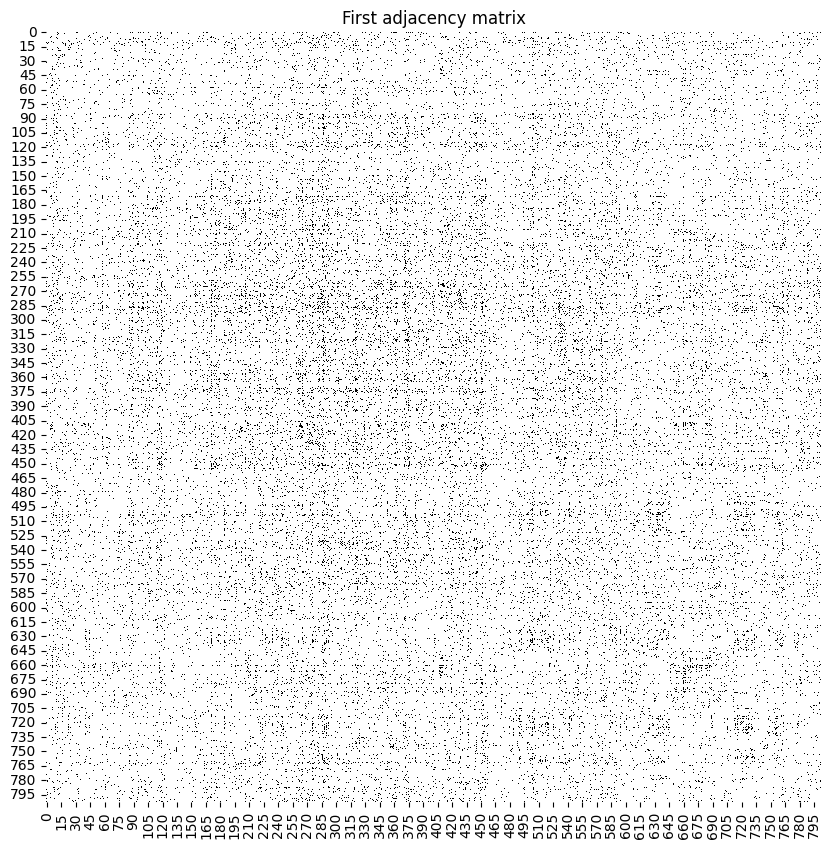

In [3]:
# load adjacency matrices 
adjacency_matrices = pickle.load(open(am_pickle_name, "rb"))

# plot first adjacency matrix 
plt.figure(figsize=(10, 10))
# nicer to print 0 as white, 1 as black -> 1 - A 
sns.heatmap(1-adjacency_matrices[0], cmap="gray", vmin=0, vmax=1, cbar=False)
plt.title("First adjacency matrix")
plt.show()


In [4]:
# Estimator run 
# Takes about 3 minutes 

np.random.seed(4321)

results = dynamic_hierarchical_dcsbm_detection_stable(
    adjacency_matrices, 
    D=10, 
    regularization_strength=3.5, 
    verbose=True
)
# save to pickle so we can easily load later 
with open(result_pickle_name, "wb") as f:
    pickle.dump(results, f)



DYNAMIC HIERARCHICAL DC-SBM COMMUNITY DETECTION
(Using Temporal Stability Method)
Data: 803 nodes, 31 time points
Edge density: 0.0570

SUPER-COMMUNITY DETECTION
Computing UASE embeddings...
Computing temporal stability scores...
Dim 0: spatial var = 0.000017, temporal var = 0.000003, ratio = 5.583
Dim 1: spatial var = 0.000164, temporal var = 0.000005, ratio = 34.190
Dim 2: spatial var = 0.000121, temporal var = 0.000007, ratio = 16.167
Dim 3: spatial var = 0.000114, temporal var = 0.000008, ratio = 13.800
Dim 4: spatial var = 0.000098, temporal var = 0.000011, ratio = 8.875
Dim 5: spatial var = 0.000087, temporal var = 0.000011, ratio = 7.737
Dim 6: spatial var = 0.000085, temporal var = 0.000011, ratio = 7.447
Dim 7: spatial var = 0.000070, temporal var = 0.000014, ratio = 4.890
Dim 8: spatial var = 0.000069, temporal var = 0.000015, ratio = 4.688
Dim 9: spatial var = 0.000065, temporal var = 0.000017, ratio = 3.840
Selected 3 stable dimensions: [1 2 3]

Estimating number of cluster